In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import (cross_validate, KFold, ShuffleSplit)

In [2]:
from ISLP.models import (ModelSpec as MS, poly, summarize)
from ISLP.models import sklearn_sm

# (a)

In [3]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2*x**2 + rng.normal(size=100)

Here n = 100, and p = 1 since only one single column predictor x is there.

Text(0, 0.5, 'y')

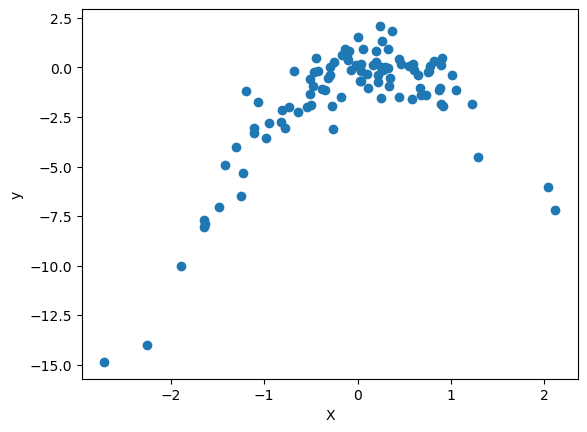

In [4]:
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel("X")
ax.set_ylabel("y")

Based on the graph, the relationship between X and y appears to be non-linear in nature.

# (c)

In [18]:
df = pd.DataFrame({"X": x, "y":y})
np.random.seed(1)

In [21]:
# (i)
model = sklearn_sm(sm.OLS, MS(['X']))
X, y = df.drop(columns=['y']), df['y']
cv_results = cross_validate(model, X, y, cv=df.shape[0])
np.mean(cv_results['test_score'])

np.float64(6.633029839181983)

In [22]:
# (ii)
df['X^2'] = df['X']**2
model = sklearn_sm(sm.OLS, MS(['X', 'X^2']))
X = df.drop(columns=['y'])
cv_results = cross_validate(model, X, y, cv = df.shape[0])
np.mean(cv_results['test_score'])

np.float64(1.1229368563419686)

In [14]:
cv_results

{'fit_time': array([0.01022625, 0.01146865, 0.01053119, 0.00886178, 0.00992417,
        0.00875521, 0.00868583, 0.00921917, 0.00642729, 0.00873494,
        0.00915074, 0.00867772, 0.00875068, 0.01004505, 0.00889301,
        0.00928998, 0.00899029, 0.00897408, 0.00853252, 0.00856519,
        0.00904131, 0.00904107, 0.00909162, 0.00884938, 0.0090158 ,
        0.00898623, 0.00821209, 0.00804949, 0.0082202 , 0.00831509,
        0.00816607, 0.00836015, 0.00786567, 0.00753593, 0.00761747,
        0.00768995, 0.00768614, 0.00779748, 0.00748873, 0.00924063,
        0.01020002, 0.00929332, 0.00814223, 0.00817323, 0.00811553,
        0.00843787, 0.00811744, 0.00823402, 0.00881481, 0.00799203,
        0.00796056, 0.0083921 , 0.00832582, 0.00846267, 0.00901318,
        0.00926948, 0.00779629, 0.00689602, 0.00897288, 0.0093379 ,
        0.00994349, 0.0102787 , 0.00862575, 0.00890398, 0.00833821,
        0.00822592, 0.0085001 , 0.00800633, 0.00827384, 0.00854325,
        0.00762796, 0.00769186, 0.00

In [23]:
# (iii)
df['X^3'] = df['X']**3
model = sklearn_sm(sm.OLS, MS(['X', 'X^2', 'X^3']))
X = df.drop(columns=['y'])
cv_results = cross_validate(model, X, y, cv = df.shape[0])
np.mean(cv_results['test_score'])

np.float64(1.3017965489358878)

In [24]:
# (iv)
df['X^4'] = df['X']**4
model = sklearn_sm(sm.OLS, MS(['X', 'X^2', 'X^3', 'X^4']))
X = df.drop(columns=['y'])
cv_results = cross_validate(model, X, y, cv = df.shape[0])
np.mean(cv_results['test_score'])

np.float64(1.332394269417931)

# (d)

In [19]:
np.random.seed(2)

In [25]:
# (i)
model = sklearn_sm(sm.OLS, MS(['X']))
X, y = df.drop(columns=['y']), df['y']
cv_results = cross_validate(model, X, y, cv=df.shape[0])
np.mean(cv_results['test_score'])

np.float64(6.633029839181983)

Yes, the results are same because in LOOCV, everytime we are leaving a single data point to be used to calculate the test score, so it doesn't depend on the random state.

# (e)

The quadratic model has the least LOOCV error. Yes, this is somewhat expected if see the graph, it looks parabolic in shape.

# (f)

In [27]:
# Linear
design = MS(['X'])
X = design.fit_transform(df)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-1.4650,0.247,-5.937,0.0
X,1.9494,0.289,6.752,0.0


In [28]:
# Quadratic
design = MS(['X', 'X^2'])
X = design.fit_transform(df)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0728,0.119,-0.611,0.543
X,0.9663,0.126,7.647,0.000
X^2,-2.0047,0.091,-22.072,0.000


In [29]:
# Cubic
design = MS(['X', 'X^2', 'X^3'])
X = design.fit_transform(df)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-0.0572,0.120,-0.477,0.635
X,1.1146,0.187,5.945,0.000
X^2,-2.0471,0.099,-20.673,0.000
X^3,-0.0643,0.060,-1.070,0.287


Yes, results aggree with cross validation results since both linear and quadratic coefficient are significant here.